# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [2]:

# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #código agregado
usage = pd.read_csv('/datasets/usage.csv') #código agregado


In [3]:
# mostrar las primeras 5 filas de plans
pd.read_csv('/datasets/plans.csv').head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
pd.read_csv('/datasets/users_latam.csv').head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
pd.read_csv('/datasets/usage.csv').head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum())
print(print(users.isna().mean()))

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64
None


In [11]:

# cantidad de nulos para usage
print(usage.isna().sum())
print(print(usage.isna().mean()))


id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64
None


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 --- 

**Valores nulos**  
- **¿Qué columnas tienen valores faltantes y en qué proporción?**
- Para users: city (11.73%) y churn_date (88.35%)
- Para usage: date (0.13%); duration (55.19%) y lenght (44.74%)
- **Indica qué harías: ¿imputar, eliminar, ignorar?**
- Para users: city (podría imputar con la moda) y churn_date (significa que el usuario continúa activo, conviene ignorar como nulo válido)
- Para suage: date (Al ser un porcentaje bajo conviene eliminar para no sesgar el análisis); duration (lo más probable es que se trate de mensajes, por eso no tienen duración, requiere más investigación antes de decidir) y lenght (Lo más probable es que se trate de llamadas, por eso no tienen un "largo", requiere más investigación antes de decidir)

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:

# explorar columnas numéricas de users
columnas_numericas_users = ['user_id', 'age']
print(users[columnas_numericas_users].describe())


            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id` ... es un identificador único, no una variable de negocio por lo tanto no tiene relevacia estadística. Los valores van de 10000 a 13999, lo que coincide con 4000 registros.
- La columna `age` ... La edad mínima es -999 años, un valor **imposible**, es señal de un valor faltante, esto **inclina la media** hacia 34 años en vez de 47 que es la mediana y hace que la **desviación estándar** (123.23) sea **exageradamente alta**. Es recomendable **reemplazar -999 por valores nulos (NaN) y volver a calcular las estadísticas**. 


In [13]:
# explorar columnas numéricas de usage
columnas_numericas_usage = ['id', 'user_id', 'duration', 'length']
print(usage[columnas_numericas_usage].describe())

                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas `id` y `user_id`: No requieren análisis estadístico ni tratamiento especial.
- Las columna **duration**:

La duración mediana es de 3.5 minutos.
El 75% de las llamadas dura menos de 7 minutos.
Existen llamadas muy largas de hasta 120 minutos. 

La media (5.20) es mayor que la mediana (3.50), lo que sugiere una **distribución sesgada hacia la derecha: Muchas llamadas cortas. Pocas llamadas muy largas que elevan el promedio**.

Posibles valores atípicos... Utilizando la regla del IQR:

IQR = 6.99 - 1.44 = 5.55

Límite superior:
6.99 + 1.5 × 5.55 = 15.32

**Las llamadas superiores a aproximadamente 15 minutos podrían considerarse valores atípicos, aunque no necesariamente errores**.

Además lo que ya se había notado en pasos anteriores: Los **valores faltantes**

De los 40,000 registros, solo 17,924 tienen duración:

40,000 - 17,924 = 22,076 valores faltantes

Esto representa aproximadamente el **55.19% de valores nulos, por lo que debe investigarse su significado antes de imputarlos**.

- La columna **lenght**:

Hay: 40,000 - 22,104 = 17,896 **valores faltantes** equivalentes al **44.74%** del total.

Al igual que con duration, **es necesario comprender qué representan esos valores faltantes antes de imputarlos**.

La longitud típica es cercana a 50 caracteres. El 50% de los mensajes tiene entre 37 y 64 caracteres.
Existen mensajes extremadamente largos de hasta 1490 caracteres.

La media (52.13) es ligeramente superior a la mediana (50), indicando una **cola derecha moderada**: La mayoría de mensajes son relativamente cortos. **Un pequeño grupo de mensajes muy largos incrementa el promedio**.

IQR = 64 - 37 = 27

Límite superior:
64 + 1.5 × 27 = 104.5

Los mensajes con más de aproximadamente 105 caracteres podrían considerarse atípicos desde el punto de vista estadístico, aunque en la práctica podrían ser completamente válidos.

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f'\nColumna: {col}')
    print(users[col].value_counts())


Columna: city
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Columna: plan
Basico     2595
Premium    1405
Name: plan, dtype: int64



- La columna `city`

Bogotá es la ciudad más representada del conjunto de datos. Le siguen: CDMX: 730 usuarios y Medellín: 616 usuarios.

La Distribución está relativamente equilibrada. La única anomalía identificada es la presencia de 96 registros con el valor "?", que deberían tratarse como datos faltantes antes de continuar con el análisis.

- La columna `plan`

Cerca de dos tercios de los usuarios utilizan el plan Básico, mientras que poco más de un tercio utiliza Premium. No se observan valores faltantes ni categorías extrañas. 

La columna 'plan' está limpia y bien estructurada. El 64.9% de los usuarios pertenece al plan Básico y el 35.1% al plan Premium. No presenta valores faltantes ni inconsistencias, por lo que está lista para utilizarse en análisis comparativos y segmentación de usuarios.


In [15]:
# explorar columna categórica de usage
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type`:

Los mensajes de texto representan un poco más de la mitad de las actividades registradas, mientras que las llamadas constituyen cerca del 45%. No se observan valores faltantes ni categorías inesperadas. 

La variable type está limpia y contiene únicamente dos categorías válidas: text (55.23%) y call (44.77%). La distribución es relativamente equilibrada y, además, esta variable explica gran parte de los valores nulos observados en duration y length, por lo que resulta fundamental para interpretar correctamente el comportamiento de los usuarios.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?

En la columna city encontré el sentinel "?" para indicar valores desconocidos/faltantes

En la columna age está el sentinel **-999 años**, un valor imposible, es señal de un valor faltante.

- ¿Qué acción tomarías?

Reemplazar **?** por valores nulos (NaN) o decidir si: **Imputarlos con la moda** (Bogotá); **Crear una categoría "Unknown"** o **Mantenerlos como nulos** si el porcentaje es bajo.

Es recomendable reemplazar **-999 por valores nulos (NaN) y volver a calcular las estadísticas**.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [18]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, ... La columna reg_date presenta una distribución muy equilibrada entre 2022 y 2024, que concentra el 99% de los usuarios. Sin embargo, la presencia de 40 registros fechados en 2026 constituye una **posible anomalía temporal que debería investigarse antes de continuar con el análisis**, ya que podría afectar la consistencia de los datos y las conclusiones obtenidas. Al no haber conlcuido 2026 es de esperarse pero habría que actualizar el df.

In [19]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()


2024.0    39950
Name: date, dtype: int64

En `date`, ... presenta una **excelente consistencia temporal**: todos los registros con fecha válida corresponden al año 2024. **Solo existen 50 valores faltantes (0.125% del total)**, una proporción suficientemente pequeña como para eliminarlos sin afectar significativamente el análisis. Además, esta información servirá como referencia para validar la coherencia temporal con otras tablas del proyecto.

Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles?
- ¿Qué harías con ellas?

Para **usage no aparecen años imposibles**.

Por tanto, no realizaría ninguna corrección sobre las fechas de usage, salvo tratar los 50 valores faltantes.

Para **users** sí existe una posible anomalía:

Los años 2022, 2023 y 2024 son coherentes. El año 2026 es sospechoso porque hay actividad de usuarios en usage durante 2024.

Antes de eliminarlos o modificarlos, investigaría: si hay usuarios que se registraron en 2026 pero aparezcan usando el servicio en 2024.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).
- Marca como nulas (`pd.NA`) las fechas fuera de rango. 

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:

# Reemplazar ? por NA en city
import numpy as np

users['city'] = users['city'].replace('?', np.nan)

# Verificar cambios
users['city'].isna().sum()


565

In [22]:
# La instrucción es marcar fechas futuras como NA para reg_date
# Sin embargo, me parece conveniente primero realizar verificaciones para saber cuál es la mejor manera
# de clasificar los valores con reg_date == 2026.

# Verificar que hay registros en 2026 con actividad en 2024
usuarios_2026 = users.loc[
    users['reg_date'].dt.year == 2026,
    'user_id'
]

usage[usage['user_id'].isin(usuarios_2026)]

,id,user_id,type,date,duration,length
61,62,10914,text,2024-01-01 06:37:29.156228905,NaN,47.0
107,108,11679,text,2024-01-01 11:37:13.765844146,NaN,57.0
473,474,11896,call,2024-01-03 03:22:08.703217580,8.28,NaN
616,617,10885,text,2024-01-03 18:53:57.380934523,NaN,32.0
650,651,11679,call,2024-01-03 22:35:30.353258831,2.76,NaN
...,...,...,...,...,...,...
39496,39497,12111,text,2024-06-27 17:22:22.203555088,NaN,47.0
39528,39529,10527,text,2024-06-27 20:50:53.236330908,NaN,59.0
39607,39608,11862,text,2024-06-28 05:25:39.848496212,NaN,65.0
39741,39742,10986,text,2024-06-28 19:58:49.798244954,NaN,57.0


In [23]:
# Verificar que no hay actividad registrada en 2026
usage[usage['date'].dt.year == 2026]

,id,user_id,type,date,duration,length


In [24]:
# Verificar que no hay actividad registrada en 2026
(usage['date'].dt.year == 2026).any()

False

In [25]:
# Marcar fechas futuras como NA para reg_date (indicación ogirinal)
# Me parece mejor reducir el año de registro 2 años, conciderando que los usuarios con reg_date == 2026 tienen actividad en 2024 y no en 2026.
users.loc[
    users['reg_date'].dt.year == 2026,
    'reg_date'
] = users['reg_date'] - pd.DateOffset(years=2)

# Verificar cambios
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1370
Name: reg_date, dtype: int64

**¿Qué cambió?**
- Antes:

2022    1314

2023    1316

**2024    1330**

**2026      40**

- Después:

2022    1314

2023    1316

**2024    1370**

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.


**Instrucciones:**

- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [26]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')[['duration', 'length']].apply(lambda x: x.isna().mean())

,duration,length
type,,
call,0.000000,0.99933
text,0.999276,0.00000


In [29]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().mean())

type
call    0.99933
text    0.00000
Name: length, dtype: float64

**Tanto para duration como para lenght:**

- Son MAR
- No se deben imputar
- No se deben eliminar
- Representan estructura del sistema, no errores.

Los valores faltantes en duration y length son MAR (Missing At Random), ya que **dependen directamente de la variable observada type**. Su ausencia es estructural: duration solo aplica a llamadas y length solo a mensajes de texto. Por lo tanto, imputarlos introduciría sesgo y distorsionaría el comportamiento real de los usuarios.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [32]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = (
    usage.groupby('user_id')
    .agg({
        'is_text': 'sum',
        'is_call': 'sum',
        'duration': 'sum'
    })
    
    .reset_index()
)


# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [33]:
# Renombrar columnas
usage_agg = (
    usage.groupby('user_id')
    .agg({
        'is_text': 'sum',
        'is_call': 'sum',
        'duration': 'sum'
    })
    .rename(columns={
        'is_text': 'cant_mensajes',
        'is_call': 'cant_llamadas',
        'duration': 'cant_minutos_llamada'
    })
    .reset_index()
)

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [34]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría. 

In [35]:
# Resumen estadístico de las columnas numéricas
user_profile[
    ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [38]:
# Distribución porcentual del tipo de plan

(user_profile['plan']
 .value_counts(normalize=True) * 100
).round(2)

Basico     64.88
Premium    35.12
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas 

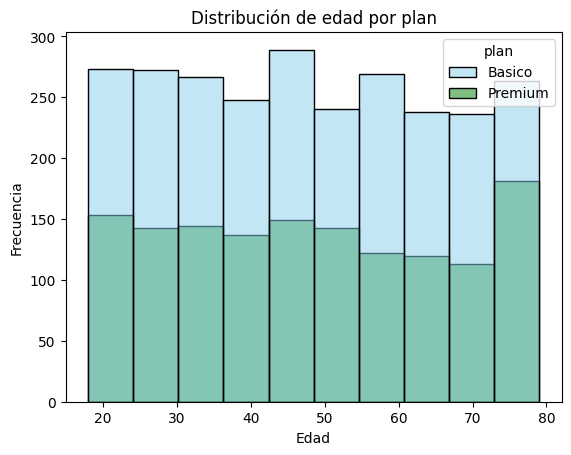

In [42]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=10
)

plt.title('Distribución de edad por plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- La edad de los usuarios se distribuye de forma relativamente uniforme entre los 18 y los 79 años. No se observan diferencias significativas entre los usuarios de los planes Básico y Premium, ya que ambos presentan una distribución similar a lo largo de todos los rangos de edad. La mayor frecuencia del plan Básico se debe a que este concentra una mayor proporción de usuarios dentro del conjunto de datos.

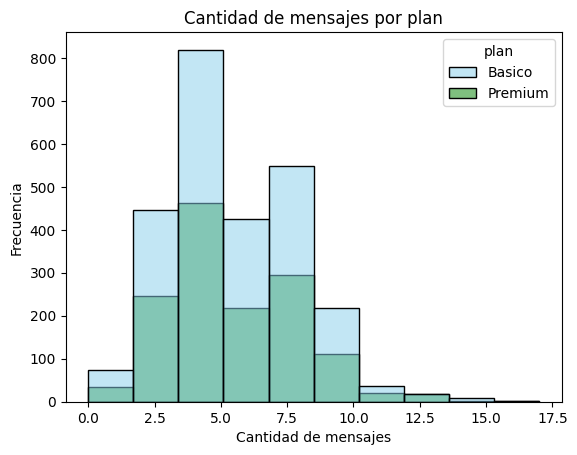

In [44]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=10
)

plt.title('Cantidad de mensajes por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- La cantidad de mensajes presenta una distribución sesgada a la derecha. La mayoría de los usuarios envía entre 3 y 8 mensajes, mientras que solo una pequeña proporción alcanza valores más altos. Al comparar los planes Básico y Premium, no se observan diferencias significativas en la distribución, aunque los usuarios Premium parecen tener una ligera mayor presencia en los rangos superiores de mensajes. 

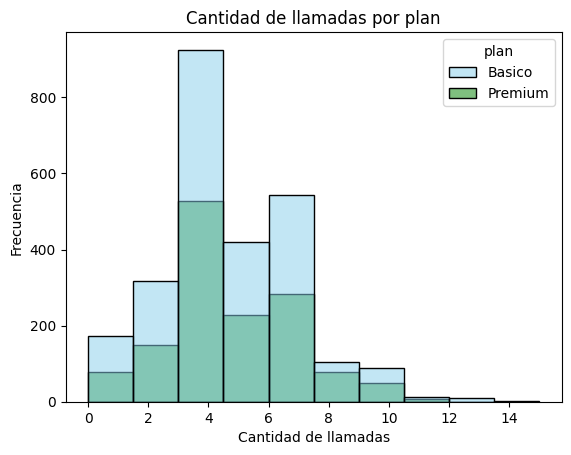

In [48]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=10
)

plt.title('Cantidad de llamadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- La cantidad de llamadas presenta una distribución sesgada a la derecha. La mayoría de los usuarios realiza entre 3 y 7 llamadas, mientras que solo una pequeña proporción supera las 10 llamadas. Al comparar los planes Básico y Premium, no se observan diferencias significativas en el patrón de uso, ya que ambas distribuciones presentan formas muy similares.

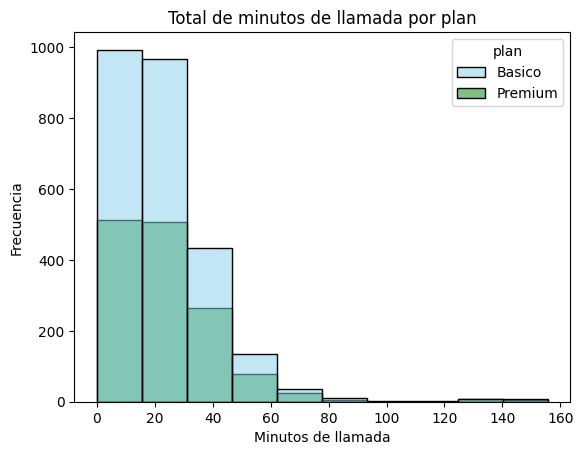

In [52]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=10
)

plt.title('Total de minutos de llamada por plan')
plt.xlabel('Minutos de llamada')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- El total de minutos de llamada presenta una distribución fuertemente sesgada a la derecha. La mayoría de los usuarios consume menos de 30 minutos de llamada, mientras que una pequeña proporción registra consumos considerablemente más altos. Al comparar los planes Básico y Premium, no se observan diferencias visuales significativas en la distribución del consumo de minutos, ya que ambos presentan un comportamiento similar. 

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada` 
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna. 

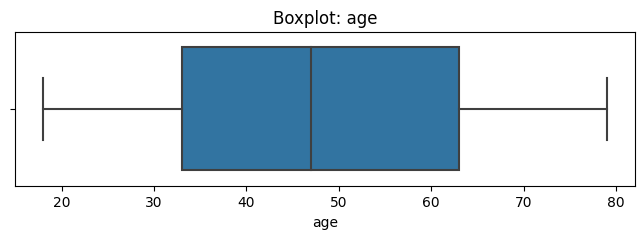

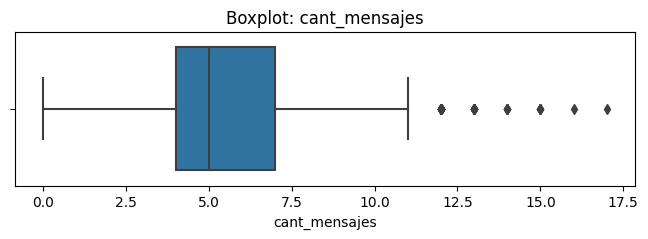

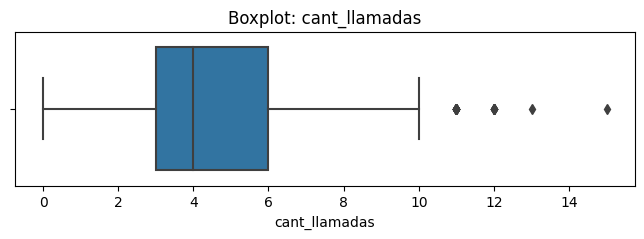

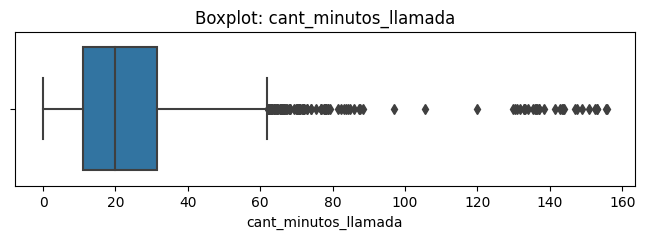

In [53]:
# Visualizando usando BoxPlot 
columnas_numericas = [
    'age',
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

for col in columnas_numericas:
    plt.figure(figsize=(8, 2))
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: no presenta outliers. Esto se había identificado desde la gráfica de su histograma. Su distribución es bastante uniforme.
- cant_mensajes: Presenta varios outliers al ser una distribución sesgada a la derecha. 
- cant_llamadas: Tambipen presenta varios outliers altos. Tiene una distribución sesgada a la derecha muy similar a cant_mensajes
- cant_minutos_llamada: El total de minutos de llamada presenta una **distribución fuertemente sesgada a la derecha**. La mayoría de los usuarios consume menos de 30 minutos de llamada, mientras que una pequeña proporción registra consumos considerablemente más altos.

In [54]:
# Calcular límites con el método IQR
columnas_limites = [
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

for col in columnas_limites:
    q1 = user_profile[col].quantile(0.25)
    q3 = user_profile[col].quantile(0.75)

    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    print(f'\n{col}')
    print(f'Límite inferior: {limite_inferior:.2f}')
    print(f'Límite superior: {limite_superior:.2f}')


cant_mensajes
Límite inferior: -0.50
Límite superior: 11.50

cant_llamadas
Límite inferior: -1.50
Límite superior: 10.50

cant_minutos_llamada
Límite inferior: -19.32
Límite superior: 61.86


In [55]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué?


Me parece que para las 3 columnas debe realizarse la misma acción ya que los outliers no son errores de registro sino comportamiento intesivo real de usuarios especiales:
- Mantener los datos
- Marcar outliers con IQR, aunque poniendo el límite inferior en 0 en lugar de los valores negativos del cálculo
- Analizar con y sin outliers mediante capado de datos
- Decidir según objetivo del modelo

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10 
  - `'Alto uso'` para el resto de casos

In [57]:
# Crear columna grupo_uso
user_profile["grupo_uso"] = np.where(
    (user_profile["cant_llamadas"] < 5) & (user_profile["cant_mensajes"] < 5),
    "Bajo uso",
    np.where(
        (user_profile["cant_llamadas"] < 10) & (user_profile["cant_mensajes"] < 10),
        "Uso medio",
        "Alto uso"
    )
)

In [58]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


In [59]:
# Celda agregada por mí para validación rápida:
user_profile["grupo_uso"].value_counts()

Uso medio    2943
Bajo uso      778
Alto uso      279
Name: grupo_uso, dtype: int64

### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna: 
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [60]:
# Crear columna grupo_edad
user_profile["grupo_edad"] = np.where(
    user_profile["age"] < 30,
    "Joven",
    np.where(
        user_profile["age"] < 60,
        "Adulto",
        "Adulto Mayor"
    )
)

In [61]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


In [62]:
# Celda de verificación agregada por mí
user_profile["grupo_edad"].value_counts()

Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64

### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`. 
- Agrega título y etiquetas a los ejes en cada gráfico.

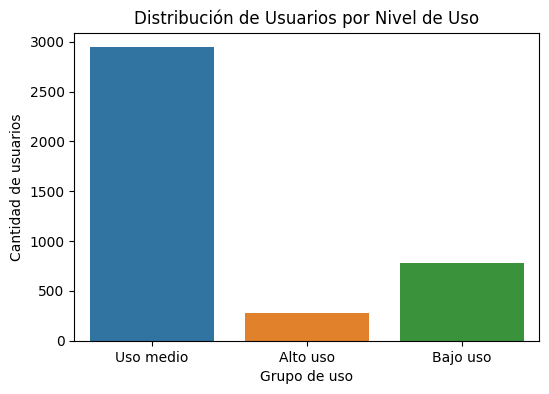

In [63]:
# Visualización de los segmentos por uso
plt.figure(figsize=(6,4))

sns.countplot(data=user_profile, x="grupo_uso")

plt.title("Distribución de Usuarios por Nivel de Uso")
plt.xlabel("Grupo de uso")
plt.ylabel("Cantidad de usuarios")

plt.show()

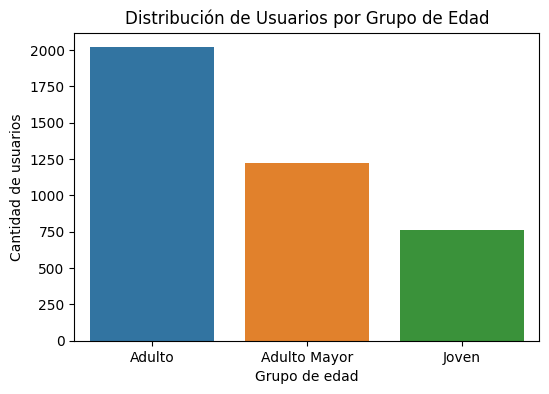

In [64]:
# Visualización de los segmentos por edad
plt.figure(figsize=(6,4))

sns.countplot(data=user_profile, x="grupo_edad")

plt.title("Distribución de Usuarios por Grupo de Edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Cantidad de usuarios")

plt.show()

In [65]:
# Celda agregada por mí para ver el porcentaje de grupo_uso
user_profile["grupo_uso"].value_counts(normalize=True) * 100

Uso medio    73.575
Bajo uso     19.450
Alto uso      6.975
Name: grupo_uso, dtype: float64

In [66]:
# Celda agregada por mí para ver el porcentaje de grupo_edad
user_profile["grupo_edad"].value_counts(normalize=True) * 100


Adulto          50.45
Adulto Mayor    30.55
Joven           19.00
Name: grupo_edad, dtype: float64

In [67]:
# Celda agregada por mí para verificar relaciones entre ambas segmentaciones:
pd.crosstab(user_profile["grupo_edad"], user_profile["grupo_uso"])

grupo_uso,Alto uso,Bajo uso,Uso medio
grupo_edad,,,
Adulto,154,364,1500
Adulto Mayor,74,257,891
Joven,51,157,552


In [68]:
# Versión por porcentajes:
pd.crosstab(
    user_profile["grupo_edad"],
    user_profile["grupo_uso"],
    normalize="index"
) * 100

grupo_uso,Alto uso,Bajo uso,Uso medio
grupo_edad,,,
Adulto,7.631318,18.037661,74.331021
Adulto Mayor,6.055646,21.031097,72.913257
Joven,6.710526,20.657895,72.631579


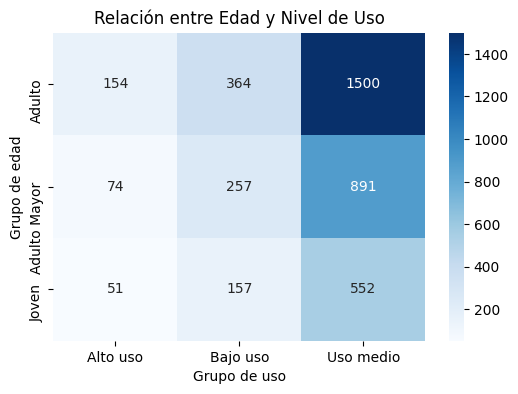

In [69]:
#Visualización de tabla cruzada
import seaborn as sns
import matplotlib.pyplot as plt

tabla_cruzada = pd.crosstab(
    user_profile["grupo_edad"],
    user_profile["grupo_uso"]
)

plt.figure(figsize=(6,4))
sns.heatmap(tabla_cruzada, annot=True, fmt="d", cmap="Blues")

plt.title("Relación entre Edad y Nivel de Uso")
plt.xlabel("Grupo de uso")
plt.ylabel("Grupo de edad")

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Datos faltantes para `users`: city (11.73%) y churn_date (88.35%)
- Datos faltantes para `usage`: date (0.13%); duration (55.19%) y lenght (44.74%). Estos faltantes son son MAR (Missing At Random), ya que **dependen directamente de la variable observada type**. Su ausencia es estructural: duration solo aplica a llamadas y length solo a mensajes de texto. Por lo tanto, imputarlos introduciría sesgo y distorsionaría el comportamiento real de los usuarios.
- La columna `age` ... La edad mínima es -999 años, un valor **imposible**, es señal de un valor faltante, esto **inclina la media** hacia 34 años en vez de 47 que es la mediana y hace que la **desviación estándar** (123.23) sea **exageradamente alta**. Se **reemplazó -999 por la mediana**.
- La columna `city`  la única anomalía identificada es la presencia de 96 registros con el valor "?" (2.72% de los datos). **Se remplazó por NaN**.
- En `reg_date`, la presencia de 40 registros fechados en 2026 aún cuando esos usuarios tienen registro de actividad sólo durante 2024. **Se redujo en 2 años la fecha de registro de 2026 a 2024**.

🔍 **Segmentos por Edad**
- La mayoría de los uruarios son `Adultos` (50.45%), seguidos por `Adultos mayores` (30.55%) y finalmente `Jóvenes` (19%).

📊 **Segmentos por Nivel de Uso**
- La mayoría de usuarios tienen un `Uso Medio` (73.58%), seguidos por un `Uso Bajo` (19.45%) y finalmente `Uso Alto` (6.97%)


➡️ Esto sugiere que
- Los `Adultos` son el segmento **más activo en consumo**.
- El `Uso medio` **domina en todos los grupos**, especialmente en `Adultos`.
- En proporción, los `Jóvenes` tienen **menor volumen total** en todos los niveles de uso.
- En resumen
    - 🟢 **Más uso intensivo**: `Adultos`
    - 🟡 **Más representativo** global: `Uso medio`
    - 🔵 **Menor adopción relativa**: `Jóvenes` y `Adultos Mayores`
    - 📊 **A mayor edad** (hasta Adulto), **mayor uso intensivo del servicio**, pero en `Adulto Mayor` el **uso** se vuelve **más mixto y menos estable**.


💡 **Recomendaciones**
- 🎯 1. Segmento clave: `Adultos`
    - enfocar planes premium
    - mejorar experiencia de uso intensivo 
- 🎯 2. `Jóvenes` = oportunidad de crecimiento
    - campañas de adopción
    - planes más baratos o digitales
    - incentivos de uso
- 🎯 3. `Adultos mayores` = segmento sensible
    - simplificación de servicio
    - soporte más guiado
    - planes básicos claros
- 🎯 4. `Uso medio` domina todo
    - el producto está funcionando como servicio cotidiano
    - pero hay margen para empujar usuarios hacia mayor uso



🧠 Insight final

El análisis muestra que el segmento de Adultos concentra el mayor nivel de uso intensivo del servicio, mientras que Jóvenes y Adultos Mayores presentan niveles más bajos o moderados. Esto sugiere oportunidades claras de segmentación de producto: expansión en usuarios jóvenes, retención y monetización en adultos, y simplificación del servicio para adultos mayores. 

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas, 
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `https://github.com/Braulio2710/sprint7-final-project`